In [1]:
!pip install kagglehub opencv-python pillow

import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms
import kagglehub

path = kagglehub.dataset_download("hutinguynhunh/garbage-classification-v2")
dataset_path = path
for _ in range(2):
    subdirs = [f.path for f in os.scandir(dataset_path) if f.is_dir()]
    if len(subdirs) == 1:
        dataset_path = subdirs[0]
    else:
        break

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.


In [2]:
classification_dataset_path = "./garbage_classification_cropped"

def process_yolo_to_classification(base_path, output_dir):
    classes = ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']

    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(base_path, split, 'images')
        lbl_dir = os.path.join(base_path, split, 'labels')

        if not os.path.exists(img_dir):
            continue

        out_split_dir = os.path.join(output_dir, split)
        for cls_name in classes:
            os.makedirs(os.path.join(out_split_dir, cls_name), exist_ok=True)

        img_paths = glob.glob(os.path.join(img_dir, '*.jpg'))

        for img_path in img_paths:
            filename = os.path.basename(img_path)
            lbl_path = os.path.join(lbl_dir, filename.replace('.jpg', '.txt'))

            if not os.path.exists(lbl_path):
                continue

            img = cv2.imread(img_path)
            if img is None:
                continue

            h, w, _ = img.shape

            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])

                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)

                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                if x2 - x1 < 10 or y2 - y1 < 10:
                    continue

                crop_img = img[y1:y2, x1:x2]
                cls_name = classes[cls_id]
                out_filename = f"{filename.replace('.jpg', '')}_crop{idx}.jpg"
                out_filepath = os.path.join(out_split_dir, cls_name, out_filename)

                cv2.imwrite(out_filepath, crop_img)

if not os.path.exists(classification_dataset_path):
    print("Đang tiền xử lý: Cắt bounding box thành ảnh phân loại độc lập...")
    process_yolo_to_classification(dataset_path, classification_dataset_path)
    print("Hoàn tất tiền xử lý.")
else:
    print("Dữ liệu đã được cắt trước đó.")

Dữ liệu đã được cắt trước đó.


In [3]:
classes_list = ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']

class SafeImageDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG'):
                    for img_path in glob.glob(os.path.join(cls_dir, ext)):
                        self.image_paths.append(img_path)
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        return image, label

    @property
    def targets(self):
        return self.labels

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

class SimpleResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SimpleResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class PureDeepCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(PureDeepCNN, self).__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = SimpleResidualBlock(64, 128, stride=2)
        self.layer2 = SimpleResidualBlock(128, 256, stride=2)
        self.layer3 = SimpleResidualBlock(256, 512, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)), #224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)), #224x224
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dir = os.path.join(classification_dataset_path, 'train')
val_dir = os.path.join(classification_dataset_path, 'valid')

train_data = SafeImageDataset(root_dir=train_dir, classes=classes_list, transform=train_transform)
val_data = SafeImageDataset(root_dir=val_dir, classes=classes_list, transform=test_transform)

target_list = torch.tensor(train_data.targets)
class_count = np.bincount(target_list.numpy(), minlength=len(classes_list))
class_count = np.maximum(class_count, 1)
class_weights = 1. / class_count
sample_weights = class_weights[target_list]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_data, batch_size=64, sampler=sampler, num_workers=0, pin_memory=False) #batch_size=128, sampler=sampler, num_workers=4, pin_memory=True
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=0, pin_memory=False) #batch_size=128, sampler=sampler, num_workers=4, pin_memory=True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

model = PureDeepCNN(num_classes=6).to(device)

criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

Epoch 1/30 [LR: 0.001000] - Train Loss: 0.6686, Train Acc: 0.5727 - Val Loss: 0.5713, Val Acc: 0.6188
Epoch 2/30 [LR: 0.001000] - Train Loss: 0.5791, Train Acc: 0.6276 - Val Loss: 0.4951, Val Acc: 0.6748
Epoch 3/30 [LR: 0.001000] - Train Loss: 0.5320, Train Acc: 0.6511 - Val Loss: 1.2664, Val Acc: 0.4478
Epoch 4/30 [LR: 0.001000] - Train Loss: 0.4767, Train Acc: 0.6808 - Val Loss: 0.4545, Val Acc: 0.6962
Epoch 5/30 [LR: 0.001000] - Train Loss: 0.4290, Train Acc: 0.7053 - Val Loss: 0.4534, Val Acc: 0.6884
Epoch 6/30 [LR: 0.001000] - Train Loss: 0.4015, Train Acc: 0.7211 - Val Loss: 0.4160, Val Acc: 0.7234
Epoch 7/30 [LR: 0.001000] - Train Loss: 0.3769, Train Acc: 0.7364 - Val Loss: 0.4273, Val Acc: 0.7224
Epoch 8/30 [LR: 0.001000] - Train Loss: 0.3545, Train Acc: 0.7501 - Val Loss: 0.4213, Val Acc: 0.7319
Epoch 9/30 [LR: 0.001000] - Train Loss: 0.3406, Train Acc: 0.7585 - Val Loss: 0.4836, Val Acc: 0.6847
Epoch 10/30 [LR: 0.001000] - Train Loss: 0.3267, Train Acc: 0.7667 - Val Loss: 0.3

/tmp/ipykernel_11166/50048837.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


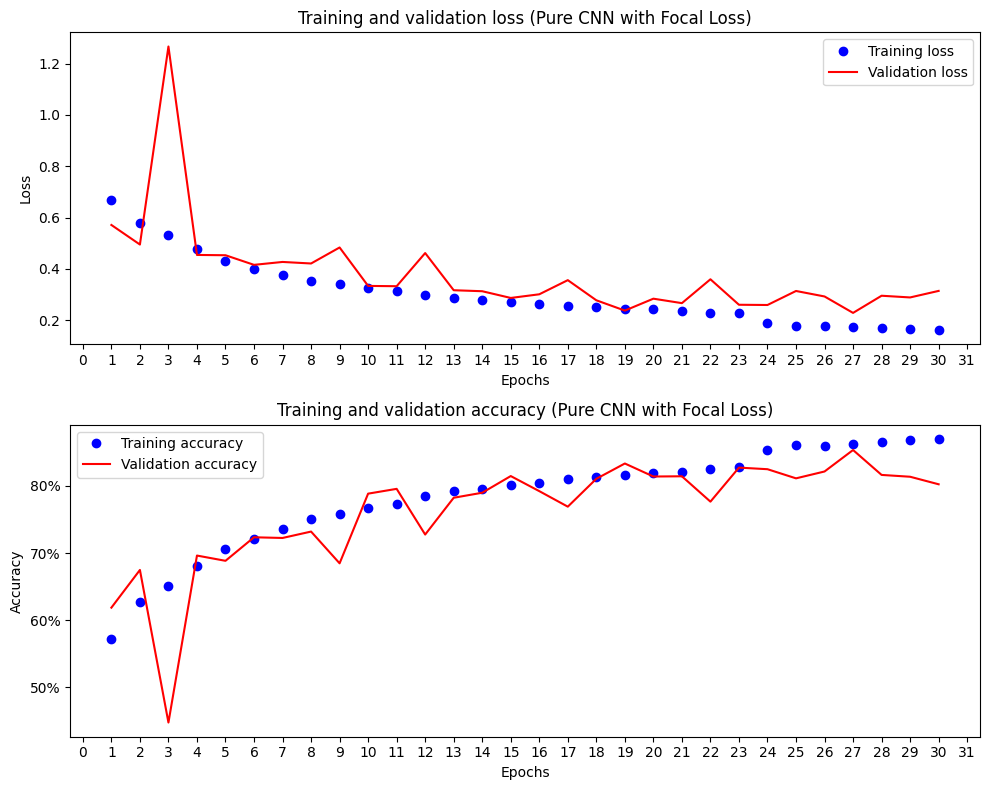

In [8]:
epochs = 30
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} [LR: {current_lr:.6f}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Trực quan hóa kết quả
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(10, 8))

plt.subplot(211)
plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss (Pure CNN with Focal Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs_range, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy (Pure CNN with Focal Loss)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()